# Posterior Analysis of MHNs

In [ ]:
import mhn
import numpy as np
import sys
sys.path.append("../MCMC-sampling-for-MHN")

from analysis.utils import plotting
import plotting

burn_in = 0.2

In [17]:
log_thetas = np.load("../results/mcmc.npy", mmap_mode="r")
log_thetas = log_thetas[:, int(log_thetas.shape[1] * 0.2):].reshape(-1, log_thetas.shape[2])
n_events = int(np.sqrt(log_thetas.shape[1]))

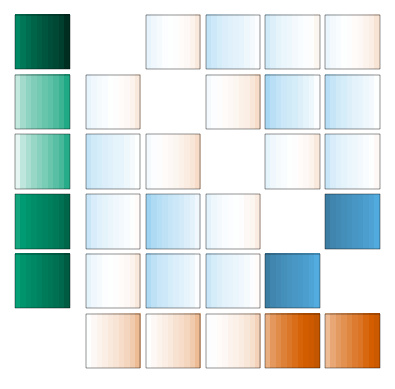

In [ ]:
tile_len = 10

quantiles = np.quantile(samples,
                        np.linspace(0.05, 0.95, tile_len),
                        axis=0).T.reshape(n_events + 1, -1)
variances = np.var(samples, axis=0).reshape(n_events + 1, -1)

fig = plt.figure(figsize=(3.21, 2.6))
gs = mpl.gridspec.GridSpec(
    3, 2, height_ratios=[1., 0.035, 0.035])

border_len = 0.1
br_ir_sep = 0.2

ax = np.array([
    fig.add_subplot(gs[0, i]) for i in range(2)])
cbar_ax = np.array([fig.add_subplot(gs[1 + i // 2, i % 2])
                   for i in range(3)])

br_min = -2.2
br_max = 3
max_abs_ir = 3.6
max_var = 0.17

data = pd.read_csv(f"../data/{data_name}.csv", index_col=0)
n_events = data.shape[1]
event_names = data.columns.tolist()

plotting.plot_theta_dist(
    quantiles=quantiles,
    tile_len=tile_len,
    n_events=n_events,
    abs_max_ir=max_abs_ir,
    min_br=br_min,
    max_br=br_max,
    events=event_names,
    ax=ax[0])
plotting.plot_theta_var(
    variances=variances,
    n_events=n_events,
    max_var=max_var,
    events=event_names,
    ax=ax[1])

ax[0].set_yticks(np.arange(0.5, n_events + 1 +
                           n_events * border_len, 1 + border_len))
ax[0].set_yticklabels(
    event_names + ["Observation"], )
ax[0].tick_params(length=0, pad=4)

for j in range(2):
    ax[j].set_xticks(
        [0.5]
        + (np.arange(1.5, n_events + 1 + n_events *
                     border_len,
                     1 + border_len) + br_ir_sep).tolist())
    ax[j].set_xticklabels([""] + event_names, rotation=90)
    ax[j].tick_params(length=0, pad=4)

cbars = list()
cbars.append(plt.colorbar(
    mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(
        vmin=-max_abs_ir, vmax=max_abs_ir), cmap=plotting.OI_RdBu),
    cax=cbar_ax[0],
    label="Influence Factors",
    orientation="horizontal",
))
cbars.append(plt.colorbar(
    mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(
        vmin=0, vmax=max_var), cmap="Greys"),
    cax=cbar_ax[1],
    label="Variances",
    orientation="horizontal",
))
cbars.append(plt.colorbar(
    mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(
        vmin=br_min, vmax=br_max), cmap=plotting.OI_Greens),
    cax=cbar_ax[2],
    label="Base Rates",
    orientation="horizontal",
))

for cbar in cbars:
    cbar.outline.set_linewidth(0.3)
    cbar.ax.tick_params(width=0.3)

fig.tight_layout()
fig.savefig(f"../results/figs/{data_name}_param_dist.pdf")